In [7]:
import numpy as np
import os
import json
import time
import pickle
import sys
import random
import itertools
import networkx as nx
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
fig = plt.figure("Degree of a random graph", figsize=(8, 8))
fig.tight_layout()


<Figure size 800x800 with 0 Axes>

In [11]:
plt.show()

In [2]:
feature_names = ["w_{}".format(ii) for ii in range(1433)]
column_names =  feature_names + ["subject"]
node_data = pd.read_csv('data/cora-raw/cora.content', sep='\t', header=None, names=column_names)

In [3]:
node_data = node_data.sort_index()

In [4]:
node_data = node_data.reset_index()

In [5]:
node_data = node_data.rename(columns={'index':'node_id'})

In [6]:
node_data # create features and labels from this 

,node_id,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7,w_8,...,w_1424,w_1425,w_1426,w_1427,w_1428,w_1429,w_1430,w_1431,w_1432,subject
0,35,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
1,40,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
2,114,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,117,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,128,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,1154500,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Case_Based
2704,1154520,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Neural_Networks
2705,1154524,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Rule_Learning
2706,1154525,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Rule_Learning


In [7]:
node_mapping = {i[0]:i[1] for i in zip(node_data['node_id'], list(range(2708)))}

In [8]:
edgelist = pd.read_csv('data/cora-raw/cora.cites', sep='\t', header=None, names=['target', 'source'])

In [9]:
edgelist

,target,source
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960
...,...,...
5424,853116,19621
5425,853116,853155
5426,853118,1140289
5427,853155,853118


In [10]:
edgelist['target'].is_monotonic_increasing

True

In [11]:
edgelist['target'] = edgelist['target'].map(node_mapping)
edgelist['source'] = edgelist['source'].map(node_mapping)

In [12]:
edgelist #convert this to csr -> this would be the adj

,target,source
0,0,21
1,0,905
2,0,906
3,0,1909
4,0,1940
...,...,...
5424,1873,328
5425,1873,1876
5426,1874,2586
5427,1876,1874


Learn the split idx based on the degrees of the nodes. The idx should ensure that the ration of the #high:low degree vertices is the same in train, val and test/

In [13]:
labels_map = {'Genetic_Algorithms':0, 'Reinforcement_Learning':1, 'Theory':2,
       'Rule_Learning':3, 'Case_Based':4, 'Probabilistic_Methods':5,
       'Neural_Networks':6}

In [14]:
node_data['subject'] = node_data['subject'].map(labels_map)

In [15]:
labels = node_data['subject'].to_numpy()

In [16]:
features = node_data.iloc[:,1:-1].to_numpy(dtype=float)

In [19]:
node_data.groupby(['subject']).count()

,node_id,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7,w_8,...,w_1423,w_1424,w_1425,w_1426,w_1427,w_1428,w_1429,w_1430,w_1431,w_1432
subject,,,,,,,,,,,,,,,,,,,,,
0,418,418,418,418,418,418,418,418,418,418,...,418,418,418,418,418,418,418,418,418,418
1,217,217,217,217,217,217,217,217,217,217,...,217,217,217,217,217,217,217,217,217,217
2,351,351,351,351,351,351,351,351,351,351,...,351,351,351,351,351,351,351,351,351,351
3,180,180,180,180,180,180,180,180,180,180,...,180,180,180,180,180,180,180,180,180,180
4,298,298,298,298,298,298,298,298,298,298,...,298,298,298,298,298,298,298,298,298,298
5,426,426,426,426,426,426,426,426,426,426,...,426,426,426,426,426,426,426,426,426,426
6,818,818,818,818,818,818,818,818,818,818,...,818,818,818,818,818,818,818,818,818,818


In [20]:
idx_list = list(map(lambda x : np.where(node_data['subject'] == x)[0], list(range(7))))

In [21]:
seed = 1234
random_state = np.random.RandomState(seed)

In [22]:
# idx_train = [random.sample(list(i), 20) for i in idx_list] # 20 labels per class in training set
idx_train = [random_state.choice(list(i), size=20, replace=False) for i in idx_list] # 20 labels per class in training set

In [23]:
idx_train = list(itertools.chain.from_iterable(idx_train)) # flatten list

In [25]:
idx_rest = list(set(node_data.index) - set(idx_train))

In [26]:
# idx_val = random.sample(idx_rest, 500)
idx_val = random_state.choice(idx_rest, size=500, replace=False)

In [37]:
idx_test = random_state.choice(list(set(idx_rest) - set(idx_val)), size=1000, replace=False)

In [29]:
edges = [(x,y) for x,y  in zip(edgelist['target'], edgelist['source'])]

In [30]:
G = nx.Graph(edges)

In [39]:
print(min(dict(G.degree).values()))
max(dict(G.degree).values())

1


168

In [66]:
from utils.data_utils import load_citation_data, load_synthetic_data, split_data

adj, features, labels, idx_train, idx_val, idx_test = load_citation_data(dataset_str='cora', use_feats=1,
                                                                          data_path='/home/luser/hgcn/data/cora', split_seed=1234)
# cardinality of each category in the training set
# print(list(map(lambda x: np.where(labels[idx_train] == x)[0].size, list(range(7)))))
G = nx.from_scipy_sparse_matrix(adj)

In [67]:
# adj, features, labels, idx_train, idx_val, idx_test = load_citation_data(dataset_str='cora', use_feats=1, data_path='/home/luser/hgcn/data/cora')
# G = nx.from_scipy_sparse_matrix(adj)

In [68]:
# adj, features, labels = load_synthetic_data(dataset_str='disease_nc', data_path='/home/luser/hgcn/data/disease_nc', use_feats=1)
# val_prop, test_prop = 0.10, 0.60

In [6]:
# idx_val, idx_test, idx_train = split_data(labels, val_prop, test_prop, seed=1234)

In [8]:
# G = nx.from_scipy_sparse_matrix(adj)

In [32]:
# print(min(dict(G.degree).values()))
# max(dict(G.degree).values())

In [63]:
# Helper function for visualization.
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

/home/luser/anaconda3/envs/hgcn/lib/python3.7/site-packages/sklearn/utils/validation.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LARGE_SPARSE_SUPPORTED = LooseVersion(scipy_version) >= '0.14.0'


In [1]:
#TODO: varying the degree distribution in the training set?

In [69]:
def plot_degree(G, degree_sequence):
    # degree_sequence = deg_test
    dmax = max(degree_sequence)
    
    #TODO: add boxplot support - compare degree distributions over differet splits

    fig = plt.figure("Degree of a random graph", figsize=(8, 8))
    # # Create a gridspec for adding subplots of different sizes
    axgrid = fig.add_gridspec(5, 4)
    
    ax0 = fig.add_subplot(axgrid[0:3, :])
    Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
    pos = nx.spring_layout(Gcc, seed=10396953)
    nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
    nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
    ax0.set_title("Connected components of G")
    ax0.set_axis_off()
    
    # ax0 = fig.add_subplot(axgrid[0:3, :])
    # ax0.boxplot(degree_sequence)
    # ax0.set_title("Connected components of G")
    # ax0.set_axis_off()
    
    ax1 = fig.add_subplot(axgrid[3:, :2])
    # ax1.plot(degree_sequence, "b-", marker="o")
    ax1.plot(degree_sequence)
    ax1.set_title("Degree Rank Plot")
    ax1.set_ylabel("Degree")
    ax1.set_xlabel("Rank")
    
    ax2 = fig.add_subplot(axgrid[3:, 2:])
    ax2.bar(*np.unique(degree_sequence, return_counts=True))
    ax2.set_title("Degree histogram")
    ax2.set_xlabel("Degree")
    ax2.set_ylabel("# of Nodes")
    
    fig.tight_layout()
    plt.show()

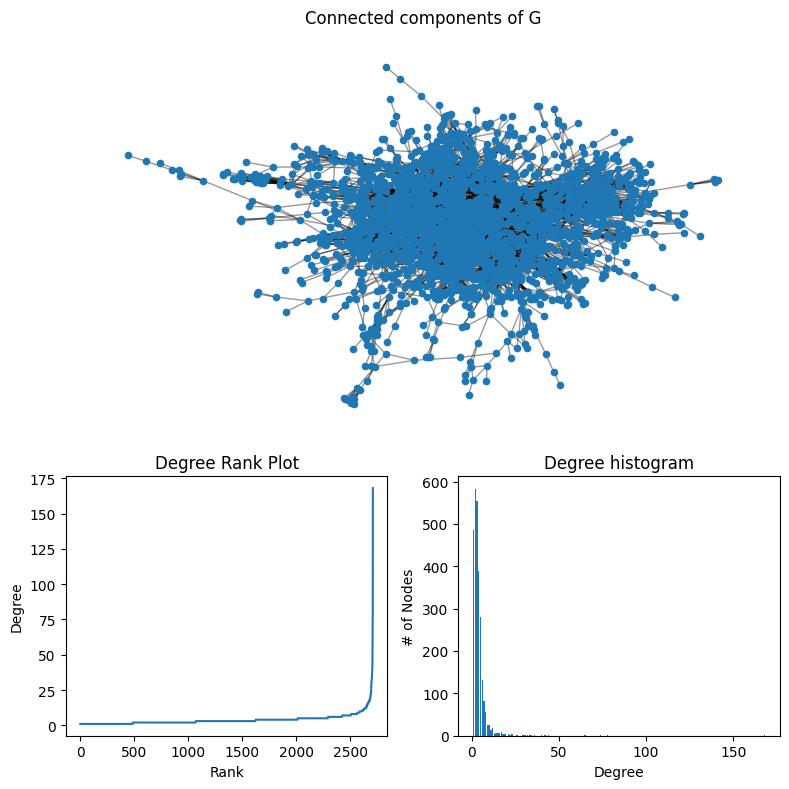

In [70]:
# Degree distribution of the whole data

# degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
degree_sequence = sorted((d for n, d in G.degree()))
plot_degree(G, degree_sequence)

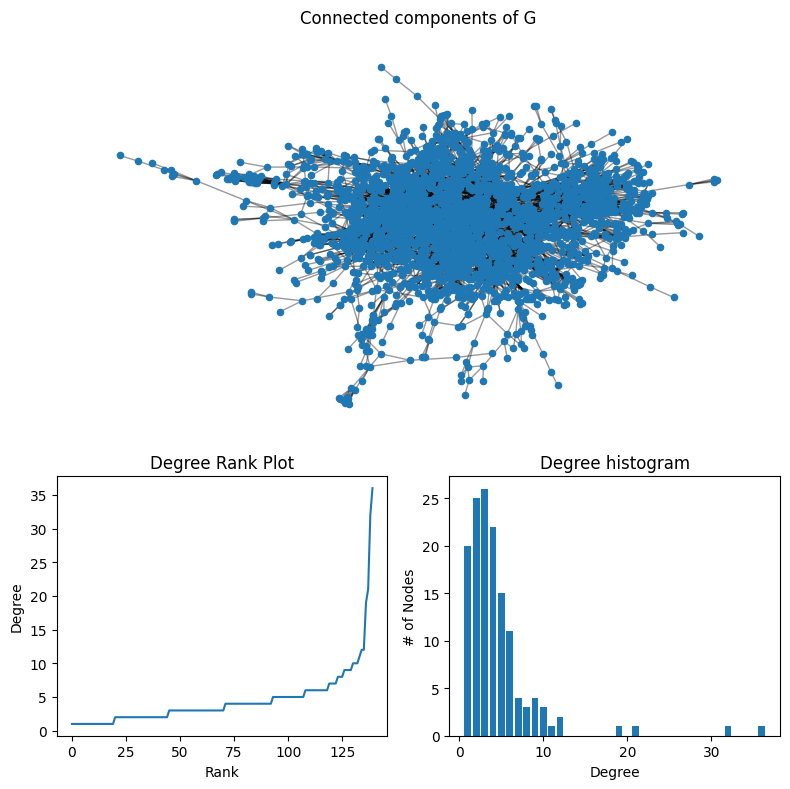

In [71]:
# Degree dsistribution of training set
dict_idx_train = {k:v for k,v in dict(G.degree).items() if k in idx_train}
degree_sequence = sorted(list(dict_idx_train.values()))
plot_degree(G, degree_sequence)

In [35]:
A = nx.adjacency_matrix(G)

In [27]:
deg_test = [list(dict(G.degree).items())[i][1] for i in idx_test]

In [28]:
print(min(deg_test))
max(deg_test)

1


7

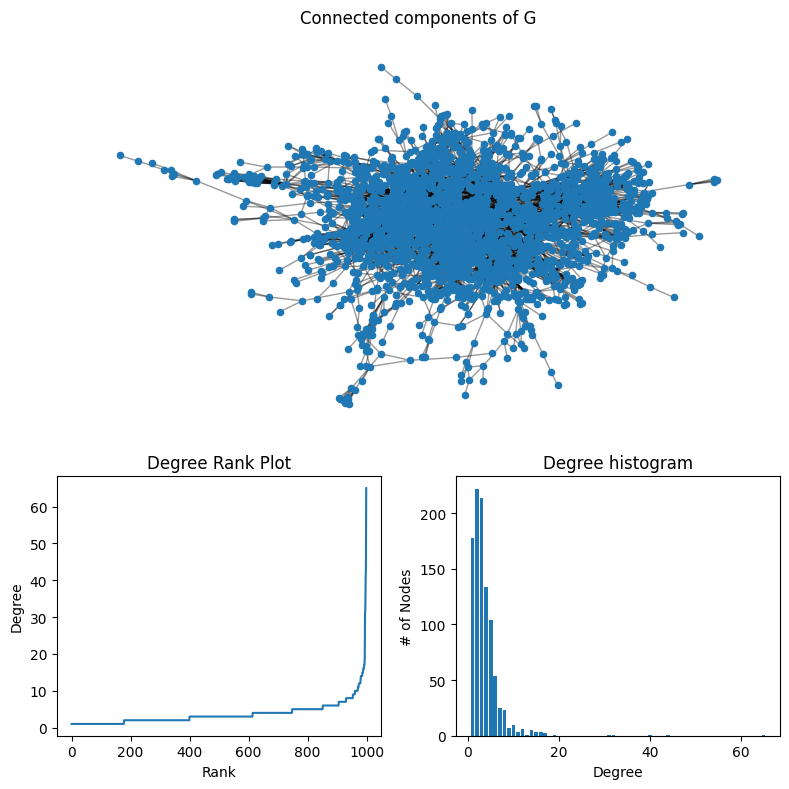

In [72]:
# Degree distribution of test set

dict_idx_test = {k:v for k,v in dict(G.degree).items() if k in idx_test}
degree_sequence = sorted(list(dict_idx_test.values()))
plot_degree(G, degree_sequence)

In [46]:
random_state = np.random.RandomState(1234)

In [55]:
idx_test_high_deg = [i[0] for i in list(dict_idx_test.items()) if i[1] > 2]

In [59]:
idx_test_not_high = list(set(idx_test) - set(idx_test_high_deg))

In [56]:
deg_val = [list(dict(G.degree).items())[i][1] for i in idx_val]

In [31]:
print(min(deg_val))
max(deg_val)

1


7

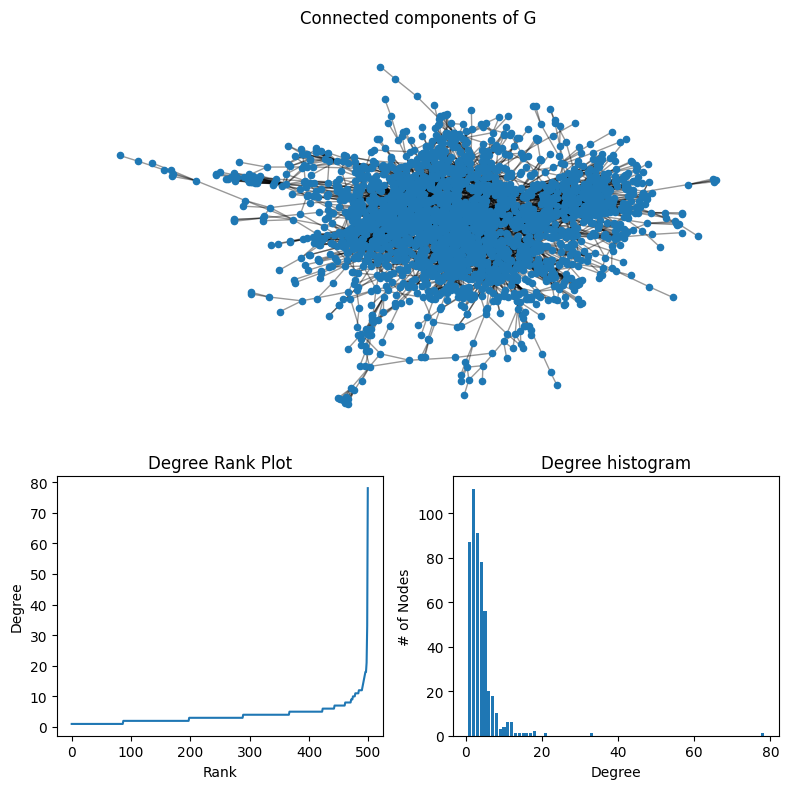

In [73]:
# Degree dsistribution of val set

dict_idx_val = {k:v for k,v in dict(G.degree).items() if k in idx_val}
degree_sequence = sorted(list(dict_idx_val.values()))
plot_degree(G, degree_sequence)

In [13]:
threshold = np.percentile(deg_test, q=75)

In [14]:
dict_idx_test = {k:v for k,v in dict(G.degree).items() if k in idx_test}

In [16]:
idx_test_high = [i[0] for i in list(dict_idx_test.items()) if i[1] > threshold]

In [17]:
idx_not_high = list(set(idx_test) - set(idx_test_high))

In [18]:
len(idx_not_high)

852

In [22]:
idx_test_low = random_state.choice(idx_not_high, size=len(idx_test_high))

In [24]:
dict_idx_high = {k:v for k,v in dict(G.degree).items() if k in idx_test_high}
dict_idx_low = {k:v for k,v in dict(G.degree).items() if k in idx_test_low}

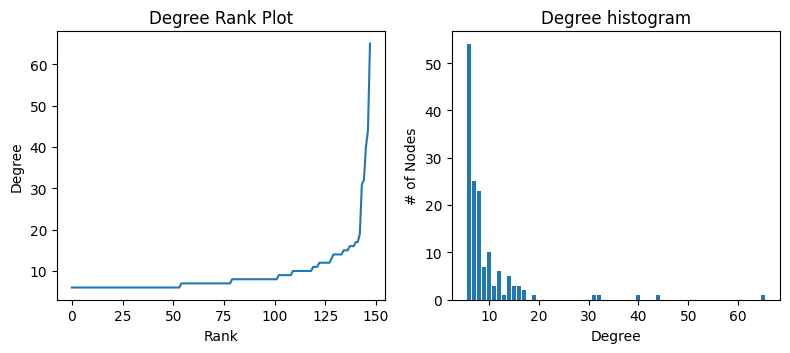

In [25]:
degree_sequence_high = sorted(list(dict_idx_high.values()))
plot_degree(degree_sequence_high)

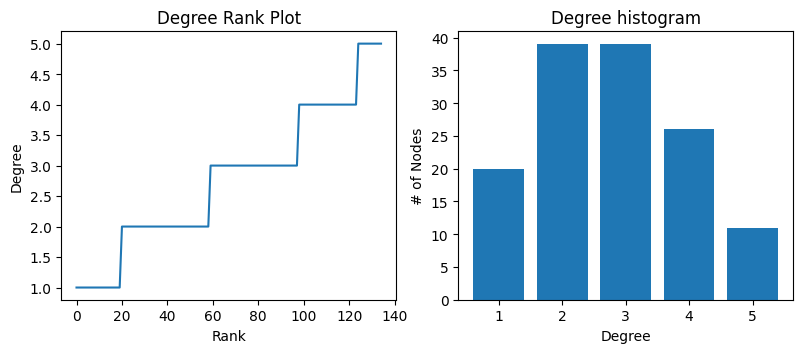

In [26]:
degree_sequence_low = sorted(list(dict_idx_low.values()))
plot_degree(degree_sequence_low)

In [8]:
res_hgcn = {'1': 0.7247191011235955, '2': 0.7432432432432432, '3': 0.8130841121495327, '4': 0.8432835820895522, '5': 0.8557692307692307, '6': 0.8518518518518519, '7': 0.8, '8': 0.8260869565217391, '9': 0.8571428571428571, '10': 1.0, '11': 0.6666666666666666, '12': 1.0, '13': 1.0, '14': 1.0, '15': 1.0, '16': 0.6666666666666666, '17': 1.0, '19': 1.0, '31': 1.0, '32': 1.0, '40': 0.0, '44': 1.0, '65': 1.0}
res_gcn = {'1': 0.7191011235955056, '2': 0.7477477477477478, '3': 0.8364485981308412, '4': 0.835820895522388, '5': 0.875, '6': 0.8703703703703703, '7': 0.76, '8': 0.7391304347826086, '9': 0.8571428571428571, '10': 0.8, '11': 0.6666666666666666, '12': 1.0, '13': 1.0, '14': 1.0, '15': 1.0, '16': 1.0, '17': 1.0, '19': 1.0, '31': 1.0, '32': 1.0, '40': 1.0, '44': 1.0, '65': 1.0}

In [13]:
x = list(res_hgcn.keys())
y_hgcn = list(res_hgcn.values())
y_gcn = list(res_gcn.values())

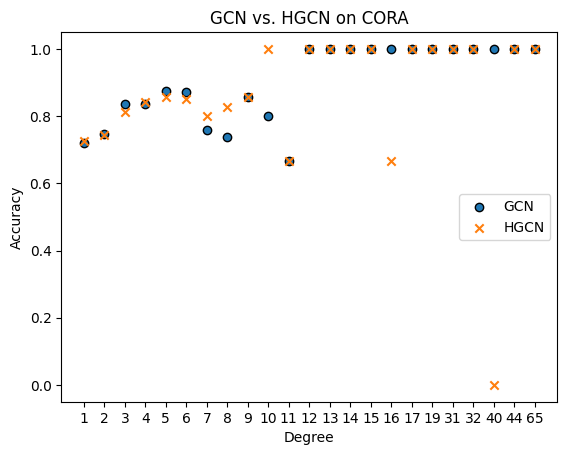

In [48]:
plt.scatter(x, y_gcn, edgecolors='k', label='GCN')
plt.scatter(x, y_hgcn, marker='x', label='HGCN')
plt.title('GCN vs. HGCN on CORA')
plt.xlabel('Degree')
plt.ylabel('Accuracy')
plt.legend(loc='center right')
plt.show()